In [28]:
import warnings
warnings.filterwarnings("ignore")

In [29]:
from tqdm import tqdm
import pandas as pd
from datetime import datetime, timedelta
import sqlite3
import mysql.connector
import pyarrow

import numpy as np

import matplotlib.pyplot as plt

In [30]:
connection = mysql.connector.connect(
    user = 'root',
    password = 'root',
    host = 'localhost',
    port = 3306,
    database = 'Historical_Data'
)
print("MySQL DB Connected")

MySQL DB Connected


In [31]:
cursor = connection.cursor()

cursor.execute("SELECT * FROM FT_DAILY_DATA WHERE Exchange = 'XRP-USD'")

results = cursor.fetchall()

columns = [column[0] for column in cursor.description]


df_original = pd.DataFrame(results, columns=columns)

In [32]:
df_original.sort_values(by = 'id_date', ascending = True)

,Open,High,Low,Close,adj_close,Volume,Exchange,id_exchange,id_date
0,0,0,0,0,0,147916992,XRP-USD,3,20171109
1,0,0,0,0,0,141032992,XRP-USD,3,20171110
2,0,0,0,0,0,134503008,XRP-USD,3,20171111
3,0,0,0,0,0,251175008,XRP-USD,3,20171112
4,0,0,0,0,0,132567000,XRP-USD,3,20171113
...,...,...,...,...,...,...,...,...,...
2379,0,1,0,1,1,1118098628,XRP-USD,3,20240515
2380,1,1,1,1,1,1152212983,XRP-USD,3,20240516
2381,1,1,1,1,1,1015239692,XRP-USD,3,20240517
2382,1,1,1,1,1,496850725,XRP-USD,3,20240518


In [33]:
df = df_original

In [34]:
df['id_date'] = pd.to_datetime(df['id_date'], format='%Y%m%d')
df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'id_date']]
df

,Open,High,Low,Close,Volume,id_date
0,0,0,0,0,147916992,2017-11-09
1,0,0,0,0,141032992,2017-11-10
2,0,0,0,0,134503008,2017-11-11
3,0,0,0,0,251175008,2017-11-12
4,0,0,0,0,132567000,2017-11-13
...,...,...,...,...,...,...
2379,0,1,0,1,1118098628,2024-05-15
2380,1,1,1,1,1152212983,2024-05-16
2381,1,1,1,1,1015239692,2024-05-17
2382,1,1,1,1,496850725,2024-05-18


In [35]:
from typing import Tuple

def train_test_split(
    df: pd.DataFrame,
    cutoff_date: datetime,
    target_column_name: str,
    ) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    """
    train_data = df[df.id_date < cutoff_date].reset_index(drop=True)
    test_data = df[df.id_date >= cutoff_date].reset_index(drop=True)

    X_train = train_data.drop(columns=[target_column_name])
    y_train = train_data[target_column_name]
    X_test = test_data.drop(columns=[target_column_name])
    y_test = test_data[target_column_name]

    return X_train, y_train, X_test, y_test

In [36]:
from datetime import datetime

X_train, y_train, X_test, y_test = train_test_split(
    df,
    cutoff_date=datetime(2023, 6, 1, 0, 0, 0),
    target_column_name='Close'
)

print(f'{X_train.shape=}')
print(f'{y_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_test.shape=}')

X_train.shape=(2030, 5)
y_train.shape=(2030,)
X_test.shape=(354, 5)
y_test.shape=(354,)


In [37]:
X_train = X_train.apply(lambda col: col.astype(int) if col.name != 'id_date' else col)
X_test = X_test.apply(lambda col: col.astype(int) if col.name != 'id_date' else col)
y_train = y_train.astype(int)
y_test = y_test.astype(int)


X_train_only_numeric = X_train.drop(columns = 'id_date')
X_test_only_numeric = X_test.drop(columns = 'id_date')



X_train_only_numeric.head(5)

,Open,High,Low,Volume
0,0,0,0,147916992
1,0,0,0,141032992
2,0,0,0,134503008
3,0,0,0,251175008
4,0,0,0,132567000


#### Linear Regression

In [38]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train_only_numeric, y_train)

LinearRegression()

In [39]:

coeffs = list(regressor.coef_)
coeffs.insert(0, regressor.intercept_)

feats2 = list(X_train_only_numeric.columns)
feats2.insert(0, 'intercept')

pd.DataFrame({'valeur estimée': coeffs}, index=feats2)

,valeur estimée
intercept,3.515821e-03
Open,-1.801674e-01
High,5.667684e-01
Low,5.972745e-01
Volume,8.282264e-13


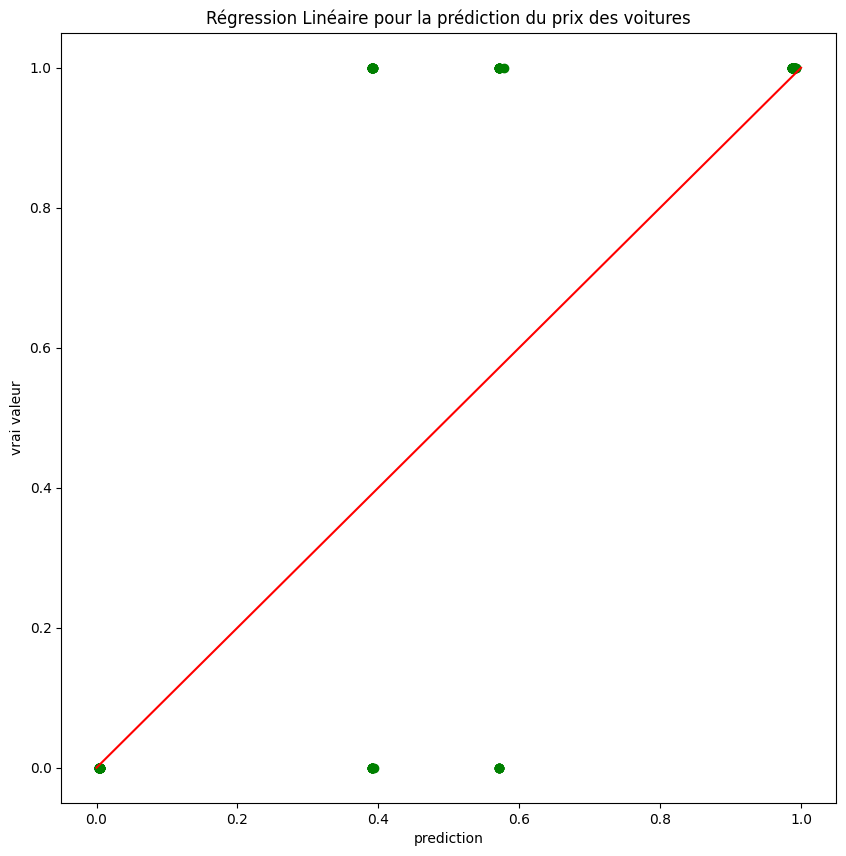

In [40]:
fig = plt.figure(figsize = (10,10))
pred_test = regressor.predict(X_test_only_numeric)
plt.scatter(pred_test, y_test, c='green')

plt.plot((y_test.min(), y_test.max()), (y_test.min(), y_test.max()), color = 'red')
plt.xlabel("prediction")
plt.ylabel("vrai valeur")
plt.title('Régression Linéaire pour la prédiction du prix des voitures')

plt.show()

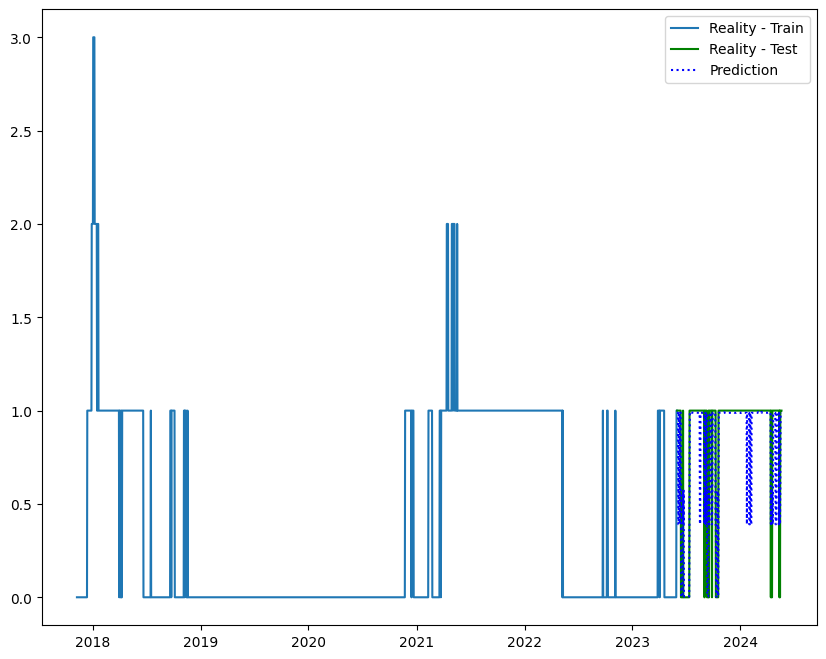

In [41]:
%matplotlib inline
fig = plt.figure(figsize = (10,8))
plt.plot(X_train['id_date'], y_train, label = 'Reality - Train')
plt.plot(X_test['id_date'], y_test, '-g', label = 'Reality - Test')
plt.plot(X_test['id_date'], pred_test, ':b', label = 'Prediction')
plt.legend()

In [42]:
def metrics_scikit_learn(y_test, predictions):
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return mse, rmse, mae, r2

print(metrics_scikit_learn(y_test, pred_test))


(0.04225551651815355, 0.20556146652073085, 0.08707165220411388, 0.668069183978629)


#### XGBOOST

In [43]:
import xgboost as xgb

In [44]:
model = xgb.XGBRegressor()

In [45]:
model.fit(X_train_only_numeric, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [46]:
predictions = model.predict(X_test_only_numeric)
predictions

array([ 1.00048459e+00,  1.01523924e+00,  9.94406819e-01,  9.99848247e-01,
        5.02252467e-02,  1.33125156e-01,  9.99741554e-01,  9.99848247e-01,
        9.98276293e-01,  7.03166574e-02,  1.00029314e+00,  1.00048459e+00,
        9.99897957e-01,  4.28027987e-01, -3.06177171e-05, -3.06177171e-05,
        5.31882906e-05,  7.91288912e-05,  7.91288912e-05, -2.85326852e-04,
        9.95591819e-01,  1.33125156e-01,  9.90158439e-01,  7.91288912e-05,
       -1.50149479e-03,  5.71050696e-05,  7.91288912e-05, -2.84888549e-04,
        7.91288912e-05, -3.75489035e-05,  7.91288912e-05, -3.06177171e-05,
        4.10949724e-05,  7.91288912e-05,  5.71050696e-05,  5.71050696e-05,
       -1.50149479e-03, -1.16449292e-03,  2.30666134e-04,  5.71050696e-05,
        5.31882906e-05,  7.91288912e-05,  5.98775089e-01,  9.93914723e-01,
        9.99283850e-01,  9.99525130e-01,  9.99897957e-01,  9.99897957e-01,
        9.99525130e-01,  9.99948680e-01,  1.00004101e+00,  9.99741554e-01,
        9.99733567e-01,  

In [47]:
from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test, predictions)
print(f'{test_mae=:.4f}')

test_mae=0.0909


In [48]:
def metrics_scikit_learn(y_test, predictions):
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return mse, rmse, mae, r2

print(metrics_scikit_learn(y_test, predictions))

(0.07610774957914744, 0.2758763302263307, 0.09092981825100353, 0.40214889072522764)


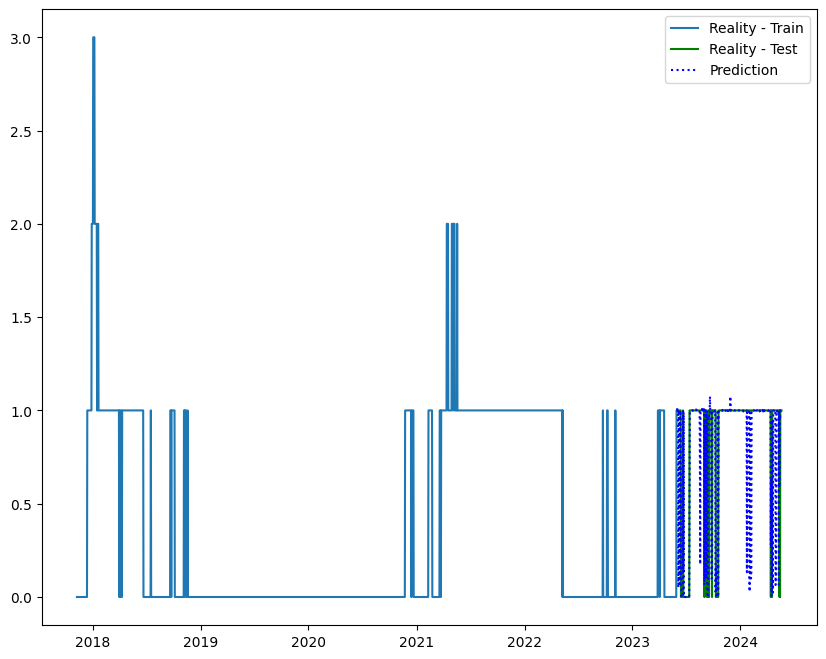

In [49]:
%matplotlib inline
fig = plt.figure(figsize = (10,8))
plt.plot(X_train['id_date'], y_train, label = 'Reality - Train')
plt.plot(X_test['id_date'], y_test, '-g', label = 'Reality - Test')
plt.plot(X_test['id_date'], predictions, ':b', label = 'Prediction')
plt.legend()



#### LIGHTGBM

In [50]:
import lightgbm as lgb

In [51]:
model_lgb = lgb.LGBMRegressor()
model_lgb.fit(X_train_only_numeric, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 268
[LightGBM] [Info] Number of data points in the train set: 2030, number of used features: 4
[LightGBM] [Info] Start training from score 0.360099
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

LGBMRegressor()

In [52]:
X_test_only_numeric = X_test.drop(columns = 'id_date')
predictions = model_lgb.predict(X_test_only_numeric)

from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test, predictions)
print(f'{test_mae=:.4f}')

test_mae=0.0852


In [53]:
def metrics_scikit_learn(y_test, predictions):
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return mse, rmse, mae, r2

print(metrics_scikit_learn(y_test, predictions))

(0.04457975930343914, 0.2111391941431982, 0.08523983718843017, 0.6498115014812399)


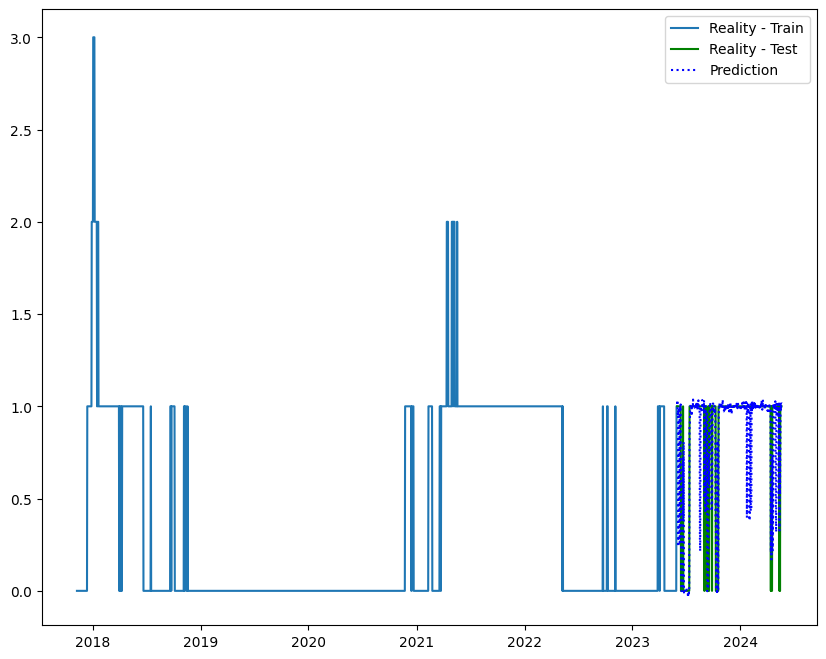

In [54]:
%matplotlib inline
fig = plt.figure(figsize = (10,8))
plt.plot(X_train['id_date'], y_train, label = 'Reality - Train')
plt.plot(X_test['id_date'], y_test, '-g', label = 'Reality - Test')
plt.plot(X_test['id_date'], predictions, ':b', label = 'Prediction')
plt.legend()

